
# 02. Dataset Profiling and Corpus Diagnostics

## Goal
Understand corpus structure before training: documents, sentences, words, vocabulary, and distribution tails.

## Theory
Poor data understanding causes poor model behavior. Profiling catches imbalance, noise, sparsity, and long-tail effects.


In [1]:

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

from utils.data import corpus_statistics, prepare_combined_corpus
from utils.reproducibility import set_global_seed

set_global_seed(42)
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

bundle = prepare_combined_corpus(
    project_root=PROJECT_ROOT,
    include_wikitext=True,
    wikitext_train_tokens=30_000,
    wikitext_val_tokens=5_000,
    wikitext_test_tokens=5_000,
)

stats = {
    "train": corpus_statistics(bundle.train_text),
    "val": corpus_statistics(bundle.val_text),
    "test": corpus_statistics(bundle.test_text),
}

pd.DataFrame(stats).T


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Building a Predictive Keyboard Model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,num_documents,num_sentences,num_words,num_unique_tokens,avg_sentence_length
train,2.0,1.0,114364.0,10730.0,114364.0
val,2.0,1.0,15545.0,3106.0,15545.0
test,2.0,1.0,15546.0,3104.0,15546.0


In [2]:

# Save profile for downstream notebooks.
out_dir = PROJECT_ROOT / "outputs" / "results"
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir / "dataset_profile_notebook.json").write_text(json.dumps(stats, indent=2), encoding="utf-8")
print("Saved profile:", out_dir / "dataset_profile_notebook.json")


Saved profile: /home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Building a Predictive Keyboard Model/outputs/results/dataset_profile_notebook.json


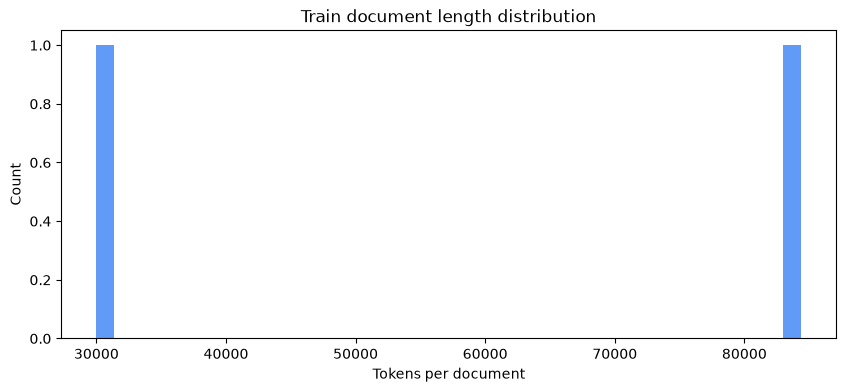

In [3]:

# Document length inspection.
def split_paragraphs(text: str):
    return [p.strip() for p in text.split("\n\n") if p.strip()]

train_docs = split_paragraphs(bundle.train_text)
lengths = [len(doc.split()) for doc in train_docs]

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=40, color="#3b82f6", alpha=0.8)
plt.title("Train document length distribution")
plt.xlabel("Tokens per document")
plt.ylabel("Count")
plt.show()



## Interpretation
- We now have real multi-source corpus.
- Vocabulary will include literary + encyclopedic styles.
- Next notebook compares tokenizer behavior before vocabulary engineering.
